# Модель для оценки рыночной стоимости недвижимости

Ноутбук демонстрирует полный ML-эксперимент для учебного проекта: генерацию синтетических данных, разведочный анализ, обучение модели, оценку качества и сохранение артефактов для Streamlit-приложения.

Основное приложение запускается из файла `app.py`, а этот ноутбук нужен для демонстрации логики работы модели и результатов эксперимента.

## 1. Подготовка окружения и путей

Ноутбук рассчитан на аккуратную структуру проекта:

```text
project/
├── app.py
├── README.md
├── requirements.txt
├── run_app.py
├── run_windows.bat
├── run_mac.command
├── run_linux.sh
├── data/
│   └── dataset.csv
├── models/
│   └── price_prediction_model.pkl
├── reports/
│   ├── metrics.txt
│   └── figures/
│       ├── price_distribution.png
│       ├── correlation_matrix.png
│       └── area_price_dependency.png
└── notebooks/
    └── WWML.ipynb
```

Если ноутбук лежит в папке `notebooks`, он сам поднимется на уровень выше и найдет корень проекта.

In [1]:
from pathlib import Path
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Определяем корень проекта.
# Если ноутбук открыт из папки notebooks, корнем считаем родительскую папку.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"notebooks", "notebook"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "dataset.csv"
MODEL_PATH = MODELS_DIR / "price_prediction_model.pkl"
METRICS_PATH = REPORTS_DIR / "metrics.txt"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Корень проекта:", PROJECT_ROOT)
print("Путь к датасету:", DATA_PATH)
print("Путь к модели:", MODEL_PATH)

Корень проекта: /mnt/data
Путь к датасету: /mnt/data/data/dataset.csv
Путь к модели: /mnt/data/models/price_prediction_model.pkl


## 2. Генерация синтетического датасета

Датасет содержит параметры квартир:

- `район` — класс района от 1 до 10, где 1 означает более престижный район;
- `площадь m^2` — площадь квартиры;
- `кол-во комнат` — количество комнат;
- `удаленность от центра (км)` — расстояние до центра;
- `этаж` — этаж квартиры;
- `цена` — целевая переменная, стоимость квартиры в рублях.

Цена рассчитывается с учетом площади, района, удаленности от центра, этажа и количества комнат. Также добавляется небольшой случайный шум, чтобы данные были ближе к реалистичным.

In [2]:
def generate_apartment():
    location = random.randint(1, 10)
    rooms = random.randint(1, 6)
    distance = round(random.uniform(0.5, 25), 2)
    floor = random.randint(1, 25)

    mean_area_by_rooms = {
        1: 38,
        2: 55,
        3: 75,
        4: 95,
        5: 115,
        6: 135,
    }

    mean_area = mean_area_by_rooms[rooms]
    std_area = 12
    area = round(np.random.normal(mean_area, std_area), 1)
    area = max(area, 15)

    base_m2_price = 150_000
    loc_coeff = 1.7 - (location / 10)
    dist_coeff = max(0.6, 1 - (distance / 50))

    if floor == 1:
        floor_coeff = 0.92
    elif 2 <= floor <= 5:
        floor_coeff = 1.00
    elif 6 <= floor <= 15:
        floor_coeff = 1.07
    elif 16 <= floor <= 22:
        floor_coeff = 1.04
    else:
        floor_coeff = 0.97

    rooms_coeff = 1 + (rooms - 2) * 0.04

    final_m2_price = (
        base_m2_price
        * loc_coeff
        * dist_coeff
        * floor_coeff
        * rooms_coeff
    )

    raw_price = area * final_m2_price * random.uniform(0.95, 1.05)
    total_price = (int(raw_price) // 10_000) * 10_000

    return {
        "район": location,
        "площадь m^2": area,
        "кол-во комнат": rooms,
        "удаленность от центра (км)": distance,
        "этаж": floor,
        "цена": total_price,
    }


def generate_data(n=1000):
    return pd.DataFrame([generate_apartment() for _ in range(n)])


data_set = generate_data(1000)
data_set.to_csv(DATA_PATH, index=False)

data_set.head()

,район,площадь m^2,кол-во комнат,удаленность от центра (км),этаж,цена
0,2,44.0,1,18.67,8,6190000
1,2,133.3,6,18.65,18,21740000
2,7,45.8,1,1.23,7,6690000
3,10,56.3,1,14.25,23,3990000
4,9,92.2,4,5.90,19,10710000


## 3. Первичная проверка данных

Проверим размер датасета, типы данных, пропуски и базовую статистику.

In [3]:
print("Размер датасета:", data_set.shape)
print("\nПропуски по столбцам:")
print(data_set.isna().sum())

print("\nОписание числовых признаков:")
data_set.describe().round(2)

Размер датасета: (1000, 6)

Пропуски по столбцам:
район                         0
площадь m^2                   0
кол-во комнат                 0
удаленность от центра (км)    0
этаж                          0
цена                          0
dtype: int64

Описание числовых признаков:


,район,площадь m^2,кол-во комнат,удаленность от центра (км),этаж,цена
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0
mean,5.57,84.62,3.44,12.75,13.70,12328490.0
std,2.89,35.63,1.73,6.97,7.01,7175880.5
min,1.00,15.00,1.00,0.54,1.00,1160000.0
25%,3.00,54.30,2.00,6.78,8.00,6690000.0
50%,6.00,82.85,3.00,12.74,14.00,10960000.0
75%,8.00,116.70,5.00,18.77,20.00,16825000.0
max,10.00,161.20,6.00,24.91,25.00,43570000.0


## 4. Разведочный анализ данных

Сначала посмотрим распределение стоимости квартир.

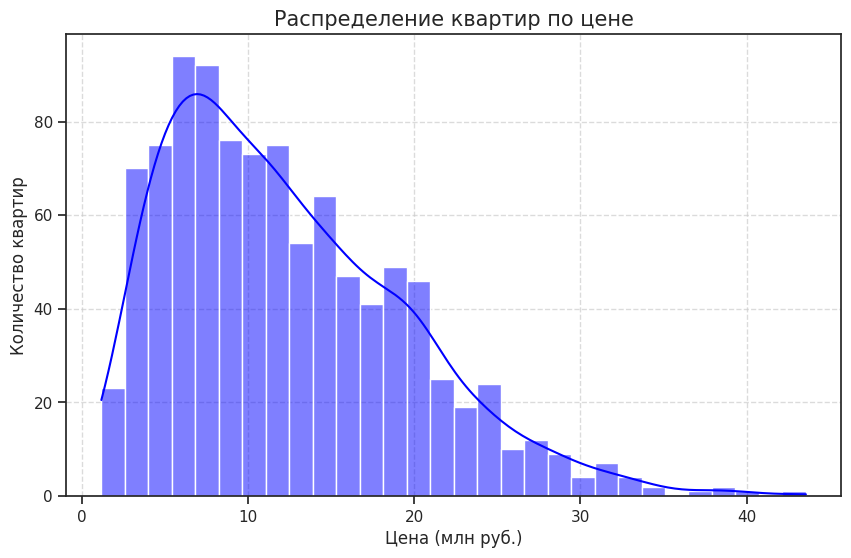

In [4]:
sns.set_theme(style="ticks", palette="pastel")

plt.figure(figsize=(10, 6))
prices_in_millions = data_set["цена"] / 1_000_000
sns.histplot(prices_in_millions, bins=30, kde=True, color="blue")
plt.title("Распределение квартир по цене", fontsize=15)
plt.xlabel("Цена (млн руб.)", fontsize=12)
plt.ylabel("Количество квартир", fontsize=12)
plt.ticklabel_format(style="plain", axis="x")
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(FIGURES_DIR / "price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Построим матрицу корреляции, чтобы увидеть связи между признаками и ценой.

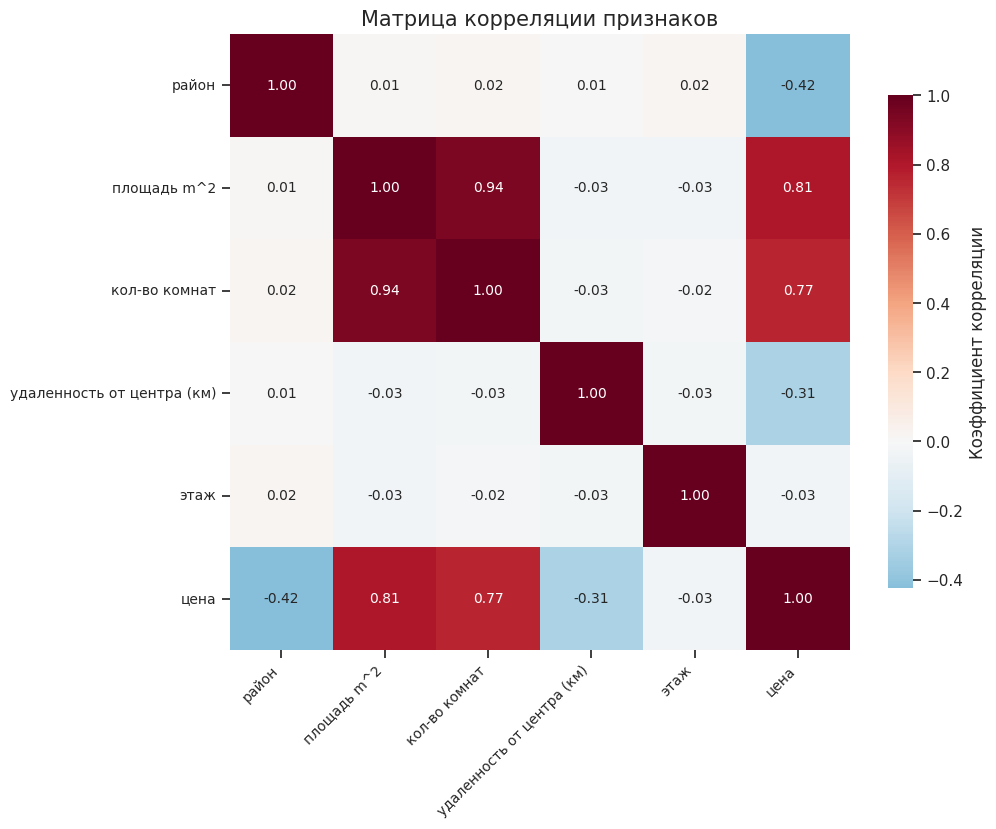

In [5]:
correlation_matrix = data_set.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
    fmt=".2f",
    annot_kws={"size": 10},
)
plt.title("Матрица корреляции признаков", fontsize=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Отдельно посмотрим зависимость цены от площади. Это один из ключевых факторов при оценке недвижимости.

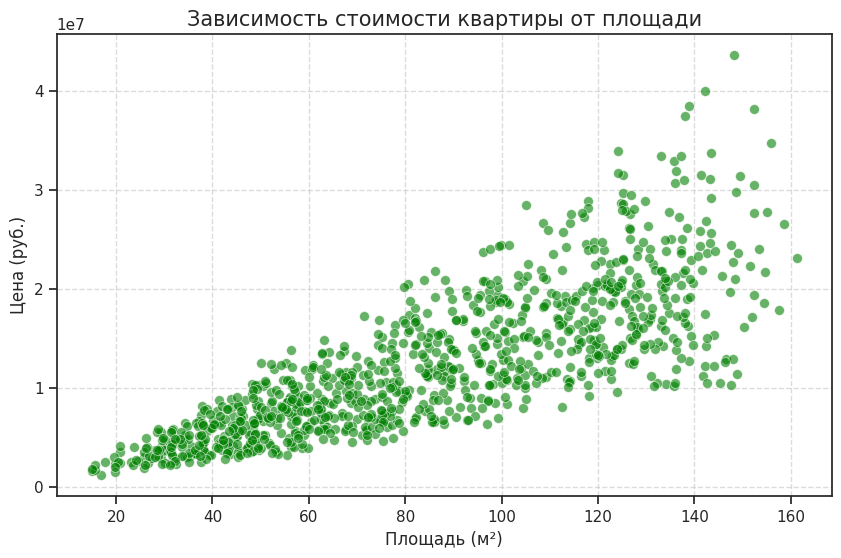

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="площадь m^2",
    y="цена",
    data=data_set,
    color="green",
    s=50,
    alpha=0.6,
)
plt.title("Зависимость стоимости квартиры от площади", fontsize=15)
plt.xlabel("Площадь (м²)", fontsize=12)
plt.ylabel("Цена (руб.)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(FIGURES_DIR / "area_price_dependency.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Обучение модели

Разделим данные на обучающую и тестовую выборки. Для сравнения обучим две модели:

1. `Linear Regression` — базовая линейная регрессия;
2. `PolynomialFeatures + StandardScaler + Ridge` — улучшенная модель с нелинейными комбинациями признаков и регуляризацией.

Основными метриками будут:

- **MAE** — средняя абсолютная ошибка в рублях;
- **RMSE** — среднеквадратичная ошибка;
- **R²** — доля объясненной дисперсии.

In [7]:
X = data_set.drop(columns=["цена"])
y = data_set["цена"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

models = {
    "Linear Regression": LinearRegression(),
    "Polynomial(2) + Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]),
}

results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    negative_predictions = int((preds < 0).sum())

    results.append({
        "Модель": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Отрицательных прогнозов": negative_predictions,
    })

    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df

,Модель,MAE,RMSE,R2,Отрицательных прогнозов
0,Polynomial(2) + Ridge,4.861209e+05,6.400735e+05,0.991996,0
1,Linear Regression,1.523506e+06,2.035483e+06,0.919059,8


## 6. Сохранение лучшей модели и метрик

Выберем модель с минимальной MAE и сохраним её в файл `models/price_prediction_model.pkl`. Этот файл используется Streamlit-приложением.

In [8]:
best_model_name = results_df.loc[0, "Модель"]
best_model = trained_models[best_model_name]

joblib.dump(best_model, MODEL_PATH)

best_row = results_df.loc[0]
metrics_text = (
    f"Best model: {best_model_name}\n"
    f"MAE:  {best_row['MAE']:,.2f}\n"
    f"RMSE: {best_row['RMSE']:,.2f}\n"
    f"R2:   {best_row['R2']:.4f}\n"
    f"Negative predictions on test: {int(best_row['Отрицательных прогнозов'])}\n"
)

METRICS_PATH.write_text(metrics_text, encoding="utf-8")

print(metrics_text)
print("Модель сохранена:", MODEL_PATH)
print("Метрики сохранены:", METRICS_PATH)

Best model: Polynomial(2) + Ridge
MAE:  486,120.90
RMSE: 640,073.50
R2:   0.9920
Negative predictions on test: 0

Модель сохранена: /mnt/data/models/price_prediction_model.pkl
Метрики сохранены: /mnt/data/reports/metrics.txt


## 7. Проверка работы модели на примере

Проверим, что модель принимает параметры квартиры и возвращает положительный прогноз стоимости.

In [9]:
example_features = pd.DataFrame([{
    "район": 3,
    "площадь m^2": 65.0,
    "кол-во комнат": 2,
    "удаленность от центра (км)": 6.5,
    "этаж": 8,
}])

predicted_price = best_model.predict(example_features)[0]
predicted_price = max(predicted_price, 0)

print(f"Прогноз стоимости: {predicted_price:,.0f} руб.")
print(f"Примерно: {predicted_price / 1_000_000:.2f} млн руб.")

Прогноз стоимости: 12,560,956 руб.
Примерно: 12.56 млн руб.


## 8. Выводы

В ходе работы был создан полный учебный ML-пайплайн:

1. Сгенерирован синтетический датасет на 1000 объектов недвижимости.
2. Проведен разведочный анализ данных: распределение цен, корреляции, зависимость цены от площади.
3. Обучены и сравнены модели регрессии.
4. Выбрана лучшая модель по MAE.
5. Модель сохранена для использования в Streamlit-приложении.
6. Метрики и графики сохранены в папку `reports`.

Ограничение проекта: модель обучена на синтетических данных, поэтому результат является ориентировочным и не может использоваться как точная рыночная оценка недвижимости.